<a href="https://colab.research.google.com/github/DanieleBaiocco/nlp_first_assignment/blob/main/nlp_0612.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 1

## Dataset preparation

In [1]:
!pip install -q -U keras-tuner

     |████████████████████████████████| 135 kB 4.7 MB/s 
     |████████████████████████████████| 1.6 MB 27.6 MB/s 


In [2]:
import os
from urllib import request
from zipfile import ZipFile
import numpy as np
import pandas as pd
import sys

import gensim
import pickle
import gensim.downloader as gloader

from keras import Sequential, Input
import keras_tuner as kt
import tensorflow as tf
from keras.optimizers import Adam, schedules
from keras.layers import Dense, Bidirectional, LSTM, Activation, TimeDistributed, Embedding, GRU, Masking, GlobalMaxPool1D, BatchNormalization, Dropout
from keras.callbacks import EarlyStopping

import copy

from sklearn.preprocessing import LabelBinarizer

In [3]:
class Dataset():

    def __init__(
        self,
        url,
        preprocessing = True,
        download_folder = "Datasets"
    ):

      self.download_extract_dataset(download_folder, url)
      self.train_list, self.val_list, self.test_list = self.build_splitted_list(download_folder, preprocessing)
      self.max_sentence_size = self.get_max_sentence_size()

    def download_extract_dataset(self, download_folder: str, url: str):
        dataset_folder = os.path.join(os.getcwd(), download_folder)
        dataset_path = os.path.join(dataset_folder, "Corpora.zip")
        if not os.path.exists(dataset_folder):
          os.makedirs(dataset_folder)
        if not os.path.exists(dataset_path):
            print("Downloading and Extracting dataset...")
            request.urlretrieve(url, dataset_path)
            with ZipFile(dataset_path, 'r') as zObject:
                zObject.extractall(
            path=dataset_folder)
            print("Done!")

    def build_splitted_list(self, download_folder: str, preprocessing: bool):
        df_rows = []

        train_list = []
        val_list = []
        test_list = []

        dataset_folder = os.path.join(os.getcwd(), download_folder, "dependency_treebank")
        list_dir = os.listdir(dataset_folder)
        list_dir.sort()

        doc_number = 1
        doc_classification = self.doc_classification(doc_number)
        
        for dir in list_dir:
            file_path = os.path.join(dataset_folder, dir)               
            if os.path.isfile(file_path):
                with open(file_path, mode = 'r', encoding = 'utf-8') as text_file:
                  critical_line = 0
                  df_row = []
                  lines = text_file.readlines()
                  for count, line in enumerate(lines):
                      splitted_line = line.split()
                      if len(splitted_line) != 3 or count + 1 >= len(lines):
                          if doc_classification == 'train':
                              train_list.append(df_row)
                          elif doc_classification == 'val':
                              val_list.append(df_row)
                          elif doc_classification == 'test':
                              test_list.append(df_row)
                          df_row = []
                          critical_line = count + 1
                          if count + 1 >= len(lines):
                              doc_number += 1
                      else:
                        if count == critical_line:
                            doc_classification = self.doc_classification(doc_number)
                        df_row.append(
                            (self.preprocessing(splitted_line[0]) if preprocessing else splitted_line[0], 
                             splitted_line[1])
                            )

        return train_list, val_list, test_list

    def doc_classification(self, doc_number):
        if doc_number <= 100:
            split = 'train'
        elif 100 < doc_number <=150:
            split= 'val'
        else: 
            split = 'test'
        return split 
    
    def preprocessing(self, word):
        wordtr = ""
        splitted_word = word.split('-')
        if len(splitted_word) > 1:
          wordtr = splitted_word[1]
        else: wordtr = splitted_word[0]
        #try:
        #    float(wordtr)
        #    wordtr = '36'
        #except ValueError:
        #   pass
        return wordtr.lower()
    
    def get_max_sentence_size(self):
        return max([len(x) for x in self.train_list + self.val_list + self.test_list])

In [4]:
url = "https://raw.githubusercontent.com/nltk/nltk_data/gh-pages/packages/corpora/dependency_treebank.zip"
data = Dataset(url = url)


Done!


## Data Analysis 

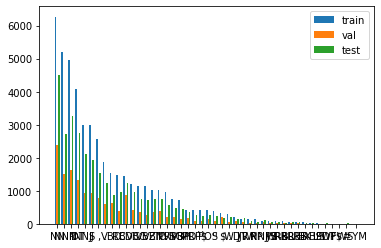

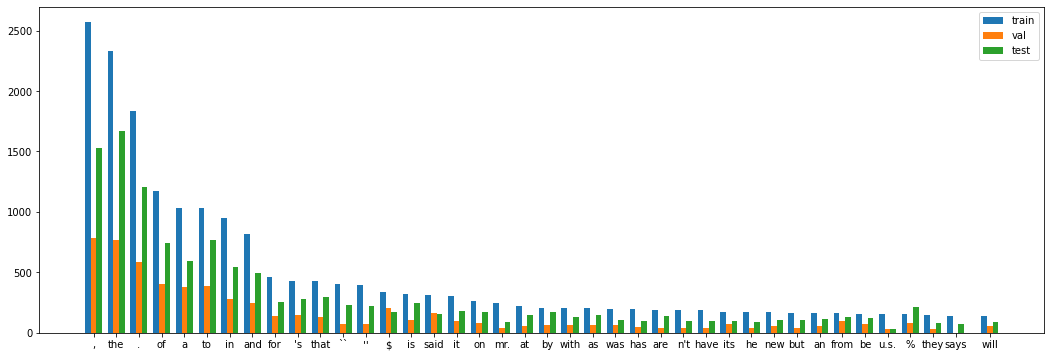

In [5]:
from collections import Counter
from collections import defaultdict
import seaborn as sns
import matplotlib.pyplot as plt

class Statistics():
  def __init__(self, train, test, val):
    train_words, train_labels = self._words_labels_arrays(train)
    val_words, val_labels = self._words_labels_arrays(val)
    test_words, test_labels = self._words_labels_arrays(test)
    self.train_words = train_words
    self.train_labels = train_labels
    self.val_words = val_words
    self.val_labels = val_labels
    self.test_words = test_words
    self.test_labels = test_labels
    self.count_train = len(train)
    self.count_val = len(val)
    self.count_test = len(test)
    self.labels = np.unique(train_labels)
    self.words = np.unique(np.concatenate([train_words, val_words, test_words])) 

  def _words_labels_arrays(_, data):
      words = []
      labels = []
      for sentence in data:
          for word in sentence:
              words.append(word[0])
              labels.append(word[1])
      return words, labels
  
  def _occurrency_counts(_, keys, a):
    dictionary = dict.fromkeys(keys, 0)
    
    unique, counts = np.unique(a, return_counts=True)
    for i in range(len(unique)):
      dictionary[unique[i]] = counts[i]
    return dictionary

  def distribution_of_splits(self):
    count_tot = self.count_train + self.count_val + self.count_test
    return self.count_train/count_tot,  self.count_val/count_tot, self.count_test/count_tot 
  
  def distribution_of_labels(self):
    oc_train, oc_val, oc_test =  self._occurrency_counts(self.labels, self.train_labels), self._occurrency_counts(self.labels, self.val_labels), self._occurrency_counts(self.labels, self.test_labels)
    return self._fill_oc_dic(oc_train, oc_val, oc_test)

  def distribution_of_words(self):
    oc_train, oc_val, oc_test =  self._occurrency_counts(self.words, self.train_words), self._occurrency_counts(self.words, self.val_words), self._occurrency_counts(self.words, self.test_words)
    return self._fill_oc_dic(oc_train, oc_val, oc_test)

  def _fill_oc_dic(_, oc_train, oc_val, oc_test):
    oc = defaultdict(list)
    for d in (oc_train, oc_val, oc_test): 
      for key, value in d.items():
        oc[key].append(value)
    return dict(sorted(oc.items(), key=lambda item: item[1][0], reverse = True))

  def label(_, i):
    label = ''
    if i == 0:
      label = 'train'
    elif i == 1:
      label = 'val'
    else: label = 'test'
    return label

  def plot_counts(self, dic, upper_bound = -1):
    top=sorted(dic.items(), key=lambda x:x[1][0],reverse=True)[:upper_bound] 
    figure = plt.figure()
    plt.rcParams['figure.figsize'] = (18.0, 6.0)
  

    x,y=zip(*top)
    n = len(x)
    r =np.linspace(1, 2*n, n, dtype = int)
    width = [-0.5, 0.0, 0.5 ]
    y= np.array(y)
    for i in range(3):
      plt.bar(r + width[i] ,y[:,i], label = self.label(i), width = 0.5)
  
    plt.xticks(r, x)
    plt.legend()
    plt.show()

train_list, val_list, test_list = data.train_list, data.val_list, data.test_list
stat = Statistics(train_list, val_list, test_list)
splits_distribution = stat.distribution_of_splits()
dic_labels = stat.distribution_of_labels()
dic_words = stat.distribution_of_words()
stat.plot_counts(dic_labels)
stat.plot_counts(dic_words, 40)


In [6]:
class Embedder():
  
    def __init__(
        self,
        data: Dataset,
        embedding_dimension = 100,
    ):
        self.embedding_model = self.load_embedding_model(embedding_dimension)
        self.embedding_dimension = embedding_dimension
        
        v1 = self.embedding_model
        oov_terms_train = self.check_OOV_terms(v1, data.train_list, "1")
        v2 = self.add_OOV_terms(v1, oov_terms_train, embedding_dimension)
        oov_terms_val = self.check_OOV_terms(v2, data.val_list, "2")
        v3 = self.add_OOV_terms(v2, oov_terms_val, embedding_dimension)
        oov_terms_test = self.check_OOV_terms(v3, data.test_list, "3")
        v4 = self.add_OOV_terms(v3, oov_terms_test, embedding_dimension)

        print(1)
        enc_X_train, y_train = self.build_embeddings_df(v2, data.train_list, embedding_dimension, data.max_sentence_size)
        enc_X_val, y_val = self.build_embeddings_df(v3, data.val_list, embedding_dimension, data.max_sentence_size)
        enc_X_test, y_test = self.build_embeddings_df(v4, data.test_list, embedding_dimension, data.max_sentence_size)

        print(2)
        self.encoder = LabelBinarizer()
        enc_y_train = self.one_hot_encode(y_train, data.max_sentence_size, is_fit = True)
        enc_y_val = self.one_hot_encode(y_val, data.max_sentence_size)
        enc_y_test = self.one_hot_encode(y_test, data.max_sentence_size)

        self.X_train = enc_X_train
        self.X_val = enc_X_val
        self.X_test = enc_X_test
        self.y_train = enc_y_train
        self.y_val = enc_y_val
        self.y_test = enc_y_test

    def load_embedding_model(self, embedding_dimension = 100):
        loading_dir_path = os.path.join(os.getcwd(), "embedding_model")
        loading_model_path = os.path.join(loading_dir_path, "model.bin")
        download_path = "glove-wiki-gigaword-{}".format(embedding_dimension)
        emb_model = gloader.load(download_path)
        return emb_model 

    def check_OOV_terms(self, vocabulary, dataset, v_num):
        embedding_vocabulary = set(vocabulary.vocab.keys())
        word_listing = set()
        for sentence in dataset:
          for couple in sentence:
            word, _ = couple
            word_listing.add(word)
        oov = word_listing.difference(embedding_vocabulary)

        oov_percentage = float(len(list(oov))) * 100 / len(word_listing)
        print(f"Total OOV terms in V{v_num}: {len(list(oov))} ({oov_percentage:.2f}%)")
        return list(oov)

    def add_OOV_terms(self, vocabulary, oov, embedding_dim):
        voc = copy.deepcopy(vocabulary)
        for word in oov:
          voc[word] = np.random.uniform(-1, 1, size=embedding_dim)
        print(f"Generated embeddings for {len(oov)} OOV words.")
        return voc

    def build_embeddings_df(self, vocabulary, df, embedding_dimension, max_sentence_size):
        df_rows = []
        ys = []
        for sentence in df:
          embeddings_row = np.array([vocabulary[word] for word, _ in sentence])
          df_rows.append(
              np.vstack(
                  (
                  embeddings_row,
                  np.zeros((max_sentence_size - len(sentence), embedding_dimension)),
                  )
              )
          )
          y = [target for _, target in sentence]
          ys.append(y)

        
        return np.array(df_rows), np.array(ys)

    def one_hot_encode(self, y, max_sentence_size, is_fit = False):
        y_onehot = []

        if is_fit:
          self.encoder.fit([word for sentence in y for word in sentence])

        for sentence in y:
          y_onehot_row = self.encoder.transform(sentence)
          padding_row = np.zeros((max_sentence_size - len(y_onehot_row), len(self.encoder.classes_)))
          y_onehot.append(
              np.vstack(
                  ( 
                    y_onehot_row,
                    padding_row,  
                  )
              )
          )
        return np.array(y_onehot)

In [7]:
embedded_data = Embedder(data)

[==================================================] 100.0% 128.1/128.1MB downloaded
Total OOV terms in V1: 157 (2.22%)
Generated embeddings for 157 OOV words.
Total OOV terms in V2: 81 (1.55%)
Generated embeddings for 81 OOV words.
Total OOV terms in V3: 68 (2.07%)
Generated embeddings for 68 OOV words.
1


<ipython-input-6-ca9580d456e3>:81: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  return np.array(df_rows), np.array(ys)


2


In [8]:
embedding_dimension = 100
num_classes = 45
input_shape = (data.max_sentence_size, embedding_dimension)

In [9]:
def baseline_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout = 0.1)))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    return model

In [10]:
baseline_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [11]:
baseline_model = baseline_model(input_shape)

In [12]:
baseline_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [13]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
baseline_model.summary()
baseline_history = baseline_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[baseline_early_stopping])

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking (Masking)           (None, 249, 100)          0         
                                                                 
 bidirectional (Bidirectiona  (None, 249, 128)         84480     
 l)                                                              
                                                                 
 time_distributed (TimeDistr  (None, 249, 45)          5805      
 ibuted)                                                         
                                                                 
Total params: 90,285
Trainable params: 90,285
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
62/62 [==============================] - 17s 84ms/step - loss: 0.2631 - accuracy: 0.3245 - val_loss: 0.1940 - val_accuracy: 0.5095
Epoch 2/50
62/62 [========================

In [14]:
def two_dense_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout=0.1)))
    model.add(TimeDistributed(Dense(units=249, activation = 'relu')))
    model.add(Dropout(rate=0.1))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    return model

In [15]:
two_dense_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [16]:
two_dense_model = two_dense_model(input_shape)

In [17]:
two_dense_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [18]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
two_dense_model.summary()
two_dense_history = two_dense_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[two_dense_early_stopping])

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_1 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_1 (Bidirectio  (None, 249, 128)         84480     
 nal)                                                            
                                                                 
 time_distributed_1 (TimeDis  (None, 249, 249)         32121     
 tributed)                                                       
                                                                 
 dropout (Dropout)           (None, 249, 249)          0         
                                                                 
 time_distributed_2 (TimeDis  (None, 249, 45)          11250     
 tributed)                                                       
                                                      

In [19]:
def two_lstm_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout=0.1)))
    model.add(Bidirectional(LSTM(64, return_sequences = True, dropout=0.1)))

    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))
    
    return model

In [20]:
two_lstm_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [21]:
two_lstm_model = two_lstm_model(input_shape)

In [22]:
two_lstm_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [23]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
two_lstm_model.summary()
two_lstm_history = two_lstm_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[two_lstm_early_stopping])

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_2 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_2 (Bidirectio  (None, 249, 128)         84480     
 nal)                                                            
                                                                 
 bidirectional_3 (Bidirectio  (None, 249, 128)         98816     
 nal)                                                            
                                                                 
 time_distributed_3 (TimeDis  (None, 249, 45)          5805      
 tributed)                                                       
                                                                 
Total params: 189,101
Trainable params: 189,101
Non-trainable params: 0
________________________________________________

In [24]:
def GRU_model(input_shape):
    model = Sequential()
    model.add(Masking(mask_value=0, input_shape=input_shape))

    model.add(Bidirectional(GRU(64, return_sequences = True, dropout=0.1)))
    model.add(TimeDistributed(Dense(num_classes, activation = 'softmax')))

    return model

In [25]:
gru_early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta = 0.008,
    patience = 5,
    restore_best_weights=True,
    verbose=True
)

In [26]:
gru_model = GRU_model(input_shape)

In [27]:
gru_model.compile(loss='categorical_crossentropy', optimizer = Adam(), metrics=["accuracy"])

In [28]:
# Build the model with the optimal hyperparameters and train it on the data for 50 epochs
gru_model.summary()
gru_history = gru_model.fit(embedded_data.X_train, embedded_data.y_train, batch_size=32, epochs=50, validation_data=(embedded_data.X_val, embedded_data.y_val), callbacks=[gru_early_stopping])

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 masking_3 (Masking)         (None, 249, 100)          0         
                                                                 
 bidirectional_4 (Bidirectio  (None, 249, 128)         63744     
 nal)                                                            
                                                                 
 time_distributed_4 (TimeDis  (None, 249, 45)          5805      
 tributed)                                                       
                                                                 
Total params: 69,549
Trainable params: 69,549
Non-trainable params: 0
_________________________________________________________________
Epoch 1/50
62/62 [==============================] - 11s 65ms/step - loss: 0.2460 - accuracy: 0.3717 - val_loss: 0.1552 - val_accuracy: 0.6077
Epoch 2/50
62/62 [======================

In [29]:
#scegliere i due modelli migliori

In [30]:
import matplotlib.pyplot as plt

def plot_history(model_history, keys, early_stopping):
    m, val_m = keys
    plt.plot(model_history.history[m][:early_stopping.best_epoch])
    plt.plot(model_history.history[val_m][:early_stopping.best_epoch])
    # plt.ylabel(m)
    # plt.xlabel('epoch')
    plt.legend(['train', 'validation'], loc='upper left')
    plt.show()


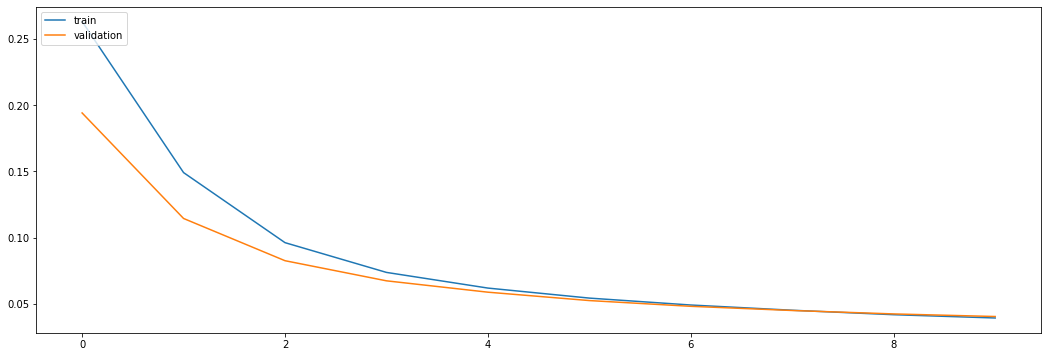

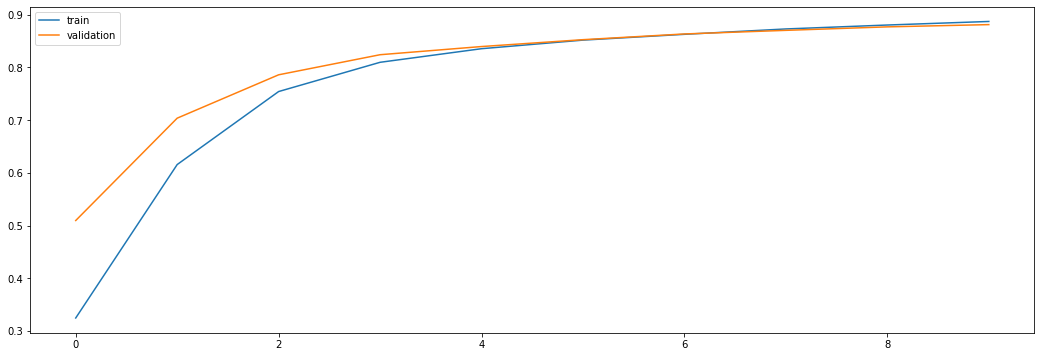

In [31]:
#baseline
plot_history(baseline_history, ['loss','val_loss'], baseline_early_stopping)
plot_history(baseline_history, ['accuracy','val_accuracy'], baseline_early_stopping)

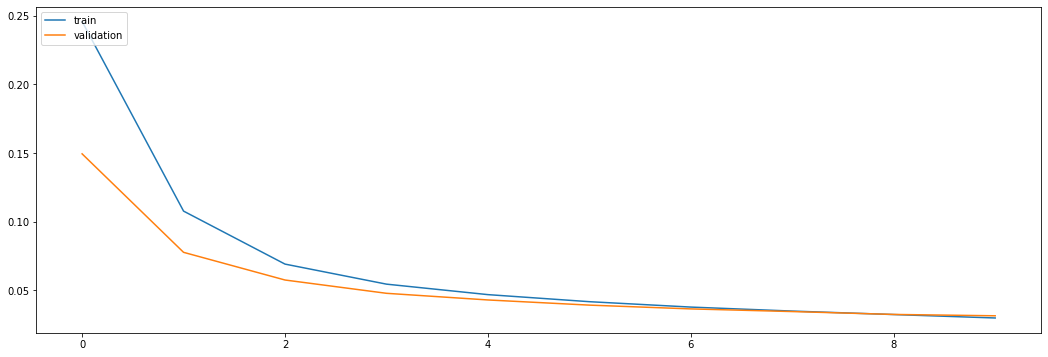

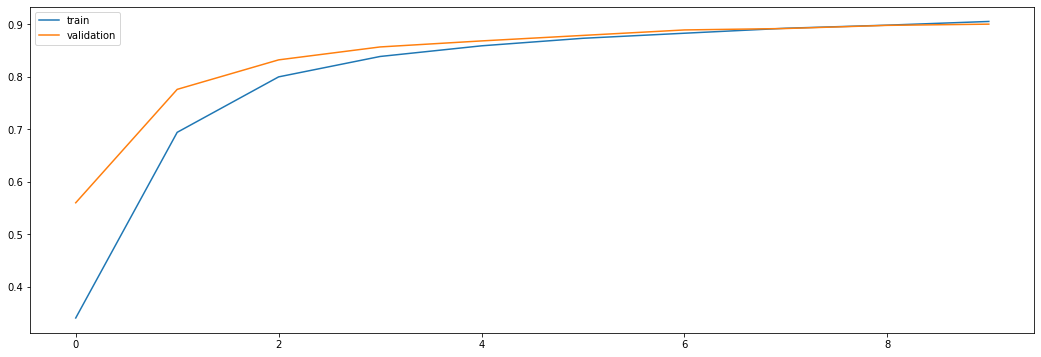

In [32]:
plot_history(two_dense_history, ['loss','val_loss'], two_dense_early_stopping)
plot_history(two_dense_history, ['accuracy','val_accuracy'], two_dense_early_stopping)

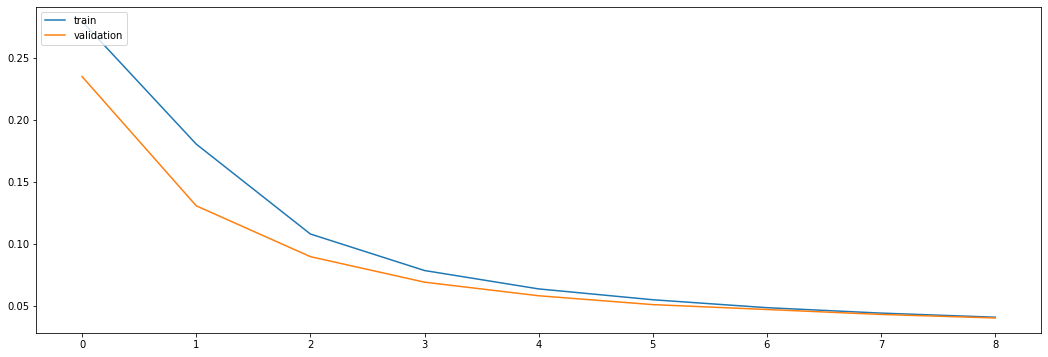

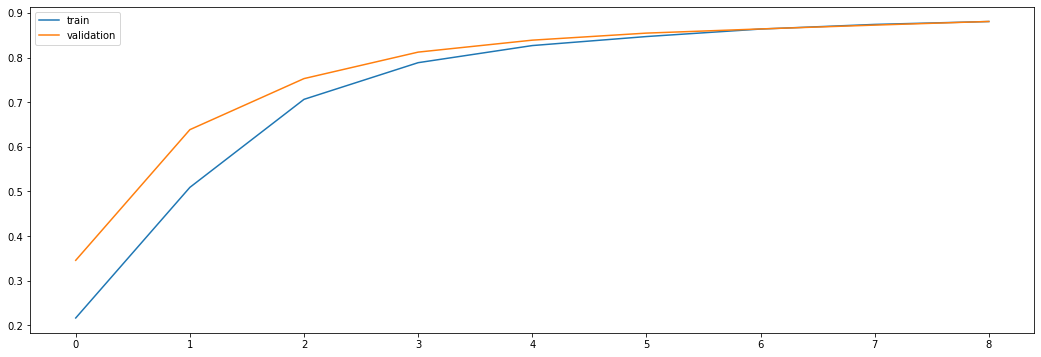

In [33]:
plot_history(two_lstm_history, ['loss','val_loss'], two_lstm_early_stopping)
plot_history(two_lstm_history, ['accuracy','val_accuracy'], two_lstm_early_stopping)

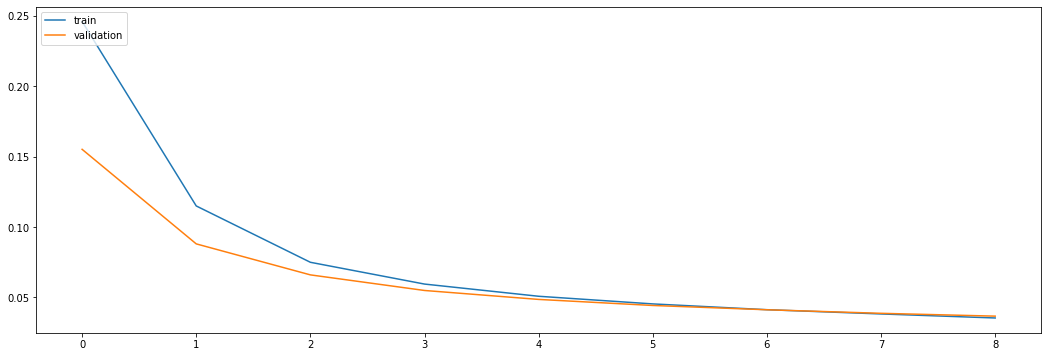

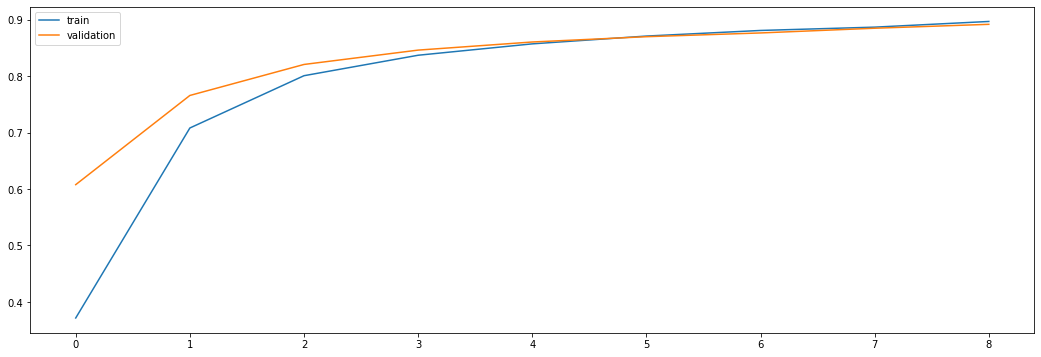

In [34]:
plot_history(gru_history, ['loss','val_loss'], gru_early_stopping)
plot_history(gru_history, ['accuracy','val_accuracy'], gru_early_stopping)

Best models are GRU and 2-Dense


In [35]:
from sklearn.metrics import f1_score

#  MODIFICARE NOMI

def prob_to_onehot(predictions):
  for sentence in predictions:
    for tag in sentence:
      max = np.argmax(np.array(tag))
      tag[max] = 1
      tag[tag!=1] = 0
  return predictions

def cut(y):
  y_cut = []
  for i, sentence in enumerate(data.test_list):
      y_cut.append(y[i][0:len(sentence)])
  return y_cut

def inverseTransform(y):
  y_cut = []
  for i in range(len(data.test_list)):
      y_cut.append(embedded_data.encoder.inverse_transform(y[i]))
  return y_cut

def remove_symbols():
  symbs = ['#', '$', "''", ',', '-LRB-', '-RRB-', '.', ':', 'SYM', '``']
  labels = list(embedded_data.encoder.classes_)
  for sym in symbs:
    labels.remove(sym)
  return labels


In [36]:
true_labels = remove_symbols()

In [41]:
y_true = embedded_data.y_test
y_true = inverseTransform(y_true)
y_true = cut(y_true)

td_y_pred = two_dense_model.predict(embedded_data.X_test)
td_y_pred = prob_to_onehot(td_y_pred)
td_y_pred = inverseTransform(td_y_pred)
td_y_pred = cut(td_y_pred)

gru_y_pred = gru_model.predict(embedded_data.X_test)
gru_y_pred = prob_to_onehot(gru_y_pred)
gru_y_pred = inverseTransform(gru_y_pred)
gru_y_pred = cut(gru_y_pred)

21/21 [==============================] - 2s 6ms/step


**F1-score deve essere calcolato su le liste trasformate: da one hot encoding a string tags**

In [43]:
from itertools import chain

flattened_y_true = list(chain.from_iterable(y_true))
flattened_td_y_pred = list(chain.from_iterable(td_y_pred))
flattened_gru_y_pred = list(chain.from_iterable(gru_y_pred))

In [44]:
f1_score(flattened_y_true, flattened_td_y_pred, labels = true_labels, average='macro', zero_division=0)

0.7135419024649018

In [45]:
f1_score(flattened_y_true, flattened_gru_y_pred, labels = true_labels, average='macro', zero_division=0)

0.6926726003434481

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

two_dense_report =  classification_report(flattened_y_true, flattened_td_y_pred, labels = true_labels, zero_division=0)
gru_report =  classification_report(flattened_y_true, flattened_gru_y_pred, labels = true_labels, zero_division=0)

In [51]:
print(two_dense_report)

              precision    recall  f1-score   support

          CC       0.99      0.99      0.99       366
          CD       0.95      0.95      0.95       858
          DT       0.99      0.99      0.99      1335
          EX       1.00      1.00      1.00         5
          FW       0.00      0.00      0.00         0
          IN       0.97      0.96      0.97      1630
          JJ       0.80      0.74      0.77       918
         JJR       0.77      0.58      0.66        59
         JJS       0.84      0.68      0.75        31
          LS       0.00      0.00      0.00         0
          MD       0.96      1.00      0.98       167
          NN       0.86      0.89      0.88      2383
         NNP       0.87      0.89      0.88      1504
        NNPS       0.00      0.00      0.00        44
         NNS       0.88      0.90      0.89       941
         PDT       0.00      0.00      0.00         4
         POS       0.99      1.00      1.00       152
         PRP       0.97    

In [52]:
print(gru_report)

              precision    recall  f1-score   support

          CC       0.99      0.99      0.99       366
          CD       0.95      0.92      0.93       858
          DT       0.98      0.99      0.98      1335
          EX       0.83      1.00      0.91         5
          FW       0.00      0.00      0.00         0
          IN       0.97      0.96      0.96      1630
          JJ       0.77      0.71      0.74       918
         JJR       0.85      0.49      0.62        59
         JJS       0.70      0.45      0.55        31
          LS       0.00      0.00      0.00         0
          MD       0.97      0.99      0.98       167
          NN       0.82      0.89      0.85      2383
         NNP       0.86      0.87      0.86      1504
        NNPS       0.50      0.02      0.04        44
         NNS       0.85      0.86      0.85       941
         PDT       0.00      0.00      0.00         4
         POS       0.99      1.00      0.99       152
         PRP       0.99    

In [53]:
two_dense_conf_matrix = confusion_matrix(flattened_y_true, flattened_td_y_pred, labels=true_labels)

In [54]:
gru_conf_matrix = confusion_matrix(flattened_y_true, flattened_gru_y_pred, labels=true_labels)

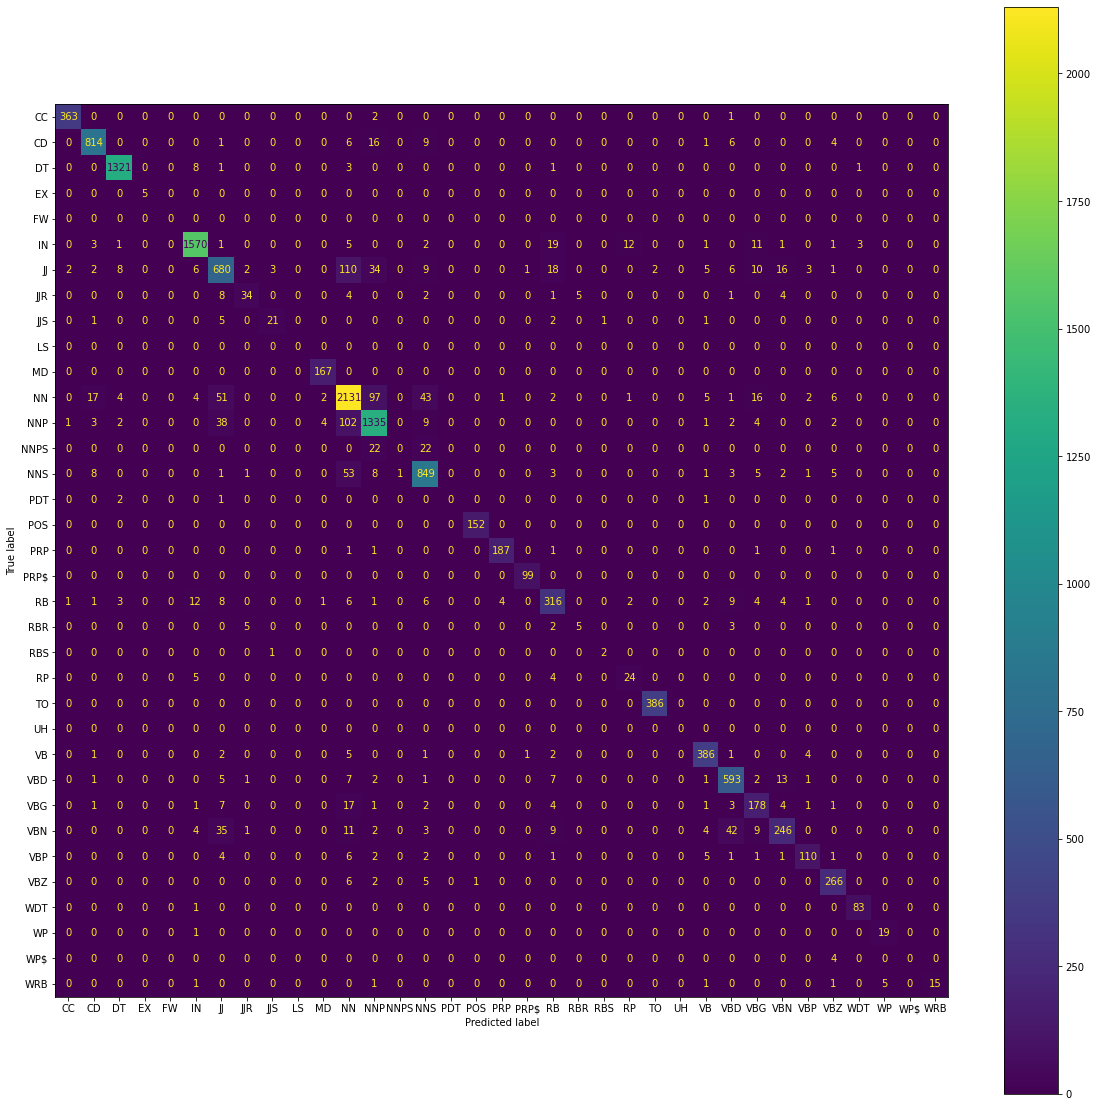

In [55]:
disp = ConfusionMatrixDisplay(two_dense_conf_matrix, display_labels = true_labels)
fig, ax = plt.subplots(figsize=(20,20))
disp.plot(ax=ax)

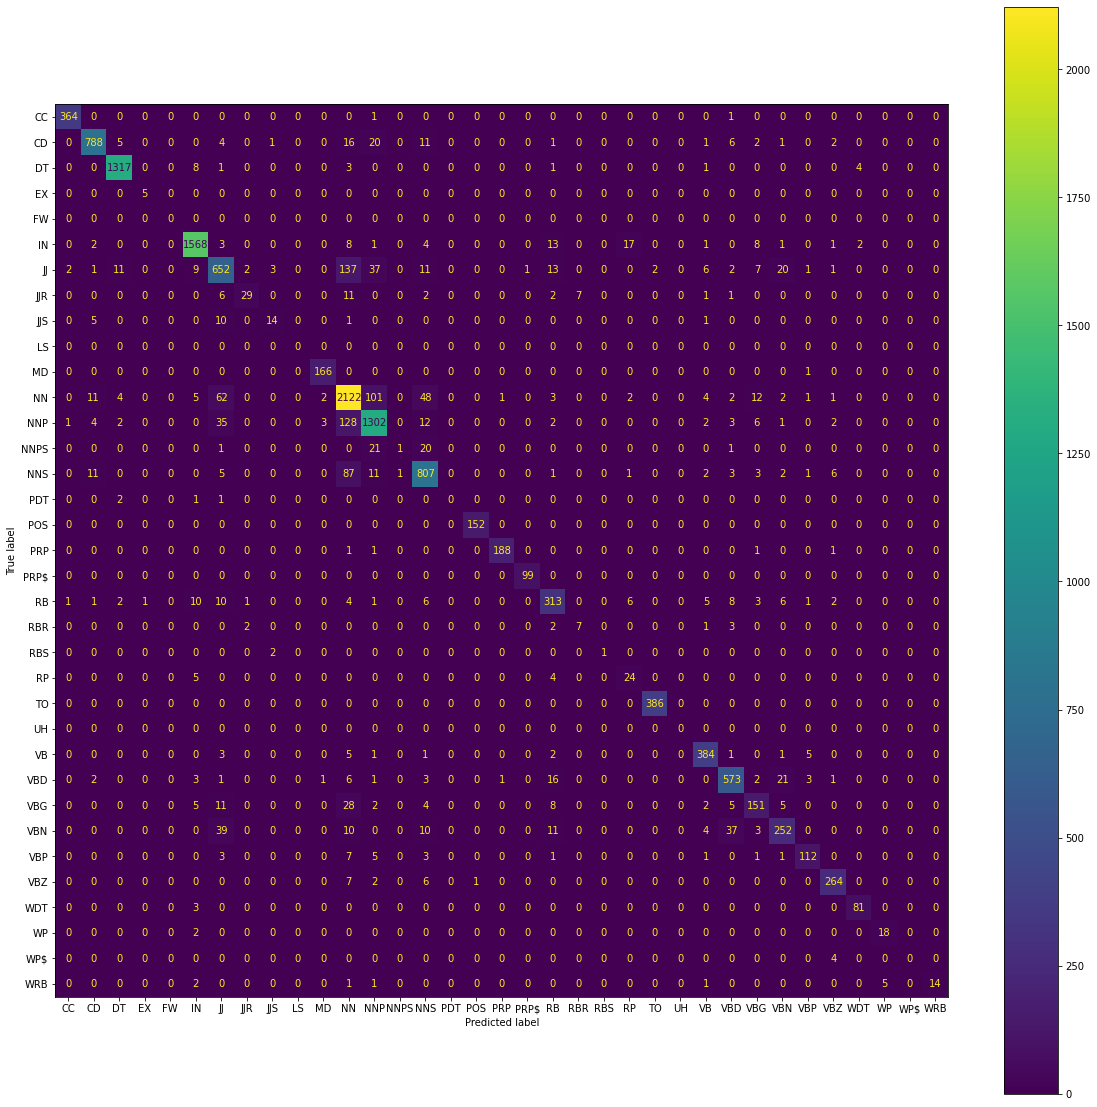

In [56]:
disp = ConfusionMatrixDisplay(gru_conf_matrix, display_labels = true_labels)
fig, ax = plt.subplots(figsize=(20, 20))
disp.plot(ax=ax)